# Feature Engineering for ML

Create features from historical returns data for machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from data_processing
# Try to load from CSV if saved, otherwise regenerate from raw data
try:
    price_df = pd.read_csv('price_data.csv', index_col=0, parse_dates=True)
    returns = pd.read_csv('returns_data.csv', index_col=0, parse_dates=True)
    stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "NVDA"]
except:
    # Regenerate from raw data if CSV not found
    print("Generating data from all_stocks_5yr.csv...")
    df = pd.read_csv("all_stocks_5yr.csv")
    df['date'] = pd.to_datetime(df['date'])
    stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "NVDA"]
    df = df[df['Name'].isin(stocks)]
    price_df = df.pivot(index='date', columns='Name', values='close').sort_index()
    returns = price_df.pct_change().dropna()
    print("✓ Data ready")

In [2]:
# Create feature matrix
features_df = returns[stocks].copy()

print(f"Initial features shape: {features_df.shape}")

Initial features shape: (1258, 7)


In [3]:
# Lagged returns (past 5 days)
for stock in stocks:
    for lag in range(1, 6):
        features_df[f'{stock}_lag{lag}'] = features_df[stock].shift(lag)

print(f"After lagged returns: {features_df.shape[1]} features")

After lagged returns: 42 features


In [4]:
# Rolling averages (5-day and 20-day)
for stock in stocks:
    features_df[f'{stock}_ma5'] = features_df[stock].rolling(5).mean()
    features_df[f'{stock}_ma20'] = features_df[stock].rolling(20).mean()

print(f"After rolling averages: {features_df.shape[1]} features")

After rolling averages: 56 features


In [5]:
# Rolling volatility (5-day window)
for stock in stocks:
    features_df[f'{stock}_vol5'] = features_df[stock].rolling(5).std()

print(f"After rolling volatility: {features_df.shape[1]} features")

After rolling volatility: 63 features


In [6]:
# Momentum indicators
for stock in stocks:
    features_df[f'{stock}_momentum'] = features_df[stock].diff()

print(f"After momentum: {features_df.shape[1]} features")

After momentum: 70 features


In [7]:
# Drop NaN values
features_df = features_df.dropna()

print(f"\nFinal feature matrix shape: {features_df.shape}")
print(f"Number of samples: {features_df.shape[0]}")
print(f"Number of features: {features_df.shape[1]}")
print(f"\nFeature list (first 15):")
print(features_df.columns.tolist()[:15])


Final feature matrix shape: (1239, 70)
Number of samples: 1239
Number of features: 70

Feature list (first 15):
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'XOM', 'NVDA', 'AAPL_lag1', 'AAPL_lag2', 'AAPL_lag3', 'AAPL_lag4', 'AAPL_lag5', 'MSFT_lag1', 'MSFT_lag2', 'MSFT_lag3']


In [8]:
# Feature statistics
print("\nFeature Statistics:")
print(features_df.describe().round(4))


Feature Statistics:
            AAPL       MSFT      GOOGL       AMZN        JPM        XOM  \
count  1239.0000  1239.0000  1239.0000  1239.0000  1239.0000  1239.0000   
mean      0.0009     0.0010     0.0008     0.0015     0.0007    -0.0001   
std       0.0146     0.0143     0.0139     0.0183     0.0128     0.0111   
min      -0.0799    -0.1140    -0.0541    -0.1100    -0.0695    -0.0569   
25%      -0.0063    -0.0058    -0.0057    -0.0071    -0.0056    -0.0056   
50%       0.0005     0.0004     0.0005     0.0011     0.0007    -0.0001   
75%       0.0086     0.0078     0.0077     0.0108     0.0075     0.0057   
max       0.0820     0.1045     0.1626     0.1413     0.0833     0.0552   

            NVDA  AAPL_lag1  AAPL_lag2  AAPL_lag3  ...   JPM_vol5   XOM_vol5  \
count  1239.0000  1239.0000  1239.0000  1239.0000  ...  1239.0000  1239.0000   
mean      0.0026     0.0009     0.0009     0.0009  ...     0.0112     0.0095   
std       0.0225     0.0146     0.0145     0.0145  ...     0.00

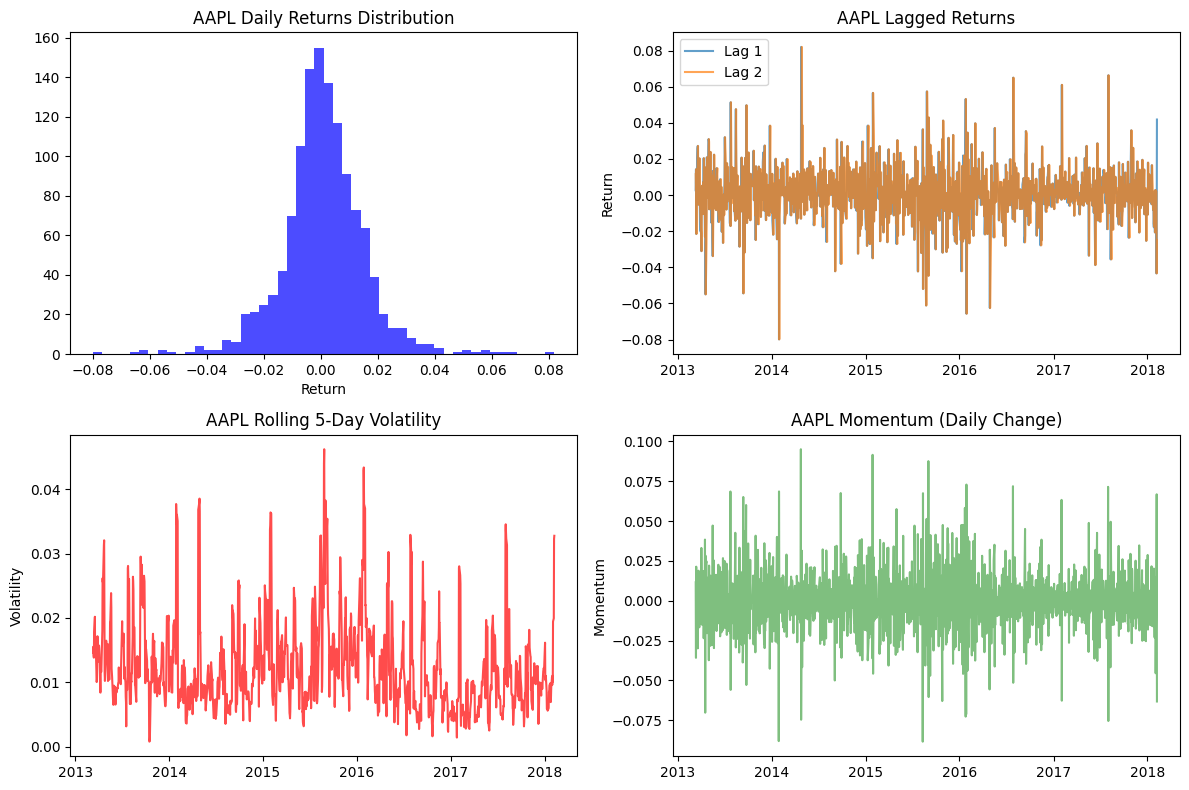

In [9]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogram of AAPL returns
axes[0, 0].hist(features_df['AAPL'], bins=50, alpha=0.7, color='blue')
axes[0, 0].set_title('AAPL Daily Returns Distribution')
axes[0, 0].set_xlabel('Return')

# Time series of AAPL lagged returns
axes[0, 1].plot(features_df.index, features_df['AAPL_lag1'], label='Lag 1', alpha=0.7)
axes[0, 1].plot(features_df.index, features_df['AAPL_lag2'], label='Lag 2', alpha=0.7)
axes[0, 1].set_title('AAPL Lagged Returns')
axes[0, 1].set_ylabel('Return')
axes[0, 1].legend()

# Rolling volatility
axes[1, 0].plot(features_df.index, features_df['AAPL_vol5'], color='red', alpha=0.7)
axes[1, 0].set_title('AAPL Rolling 5-Day Volatility')
axes[1, 0].set_ylabel('Volatility')

# Momentum
axes[1, 1].plot(features_df.index, features_df['AAPL_momentum'], color='green', alpha=0.5)
axes[1, 1].set_title('AAPL Momentum (Daily Change)')
axes[1, 1].set_ylabel('Momentum')

plt.tight_layout()
plt.show()

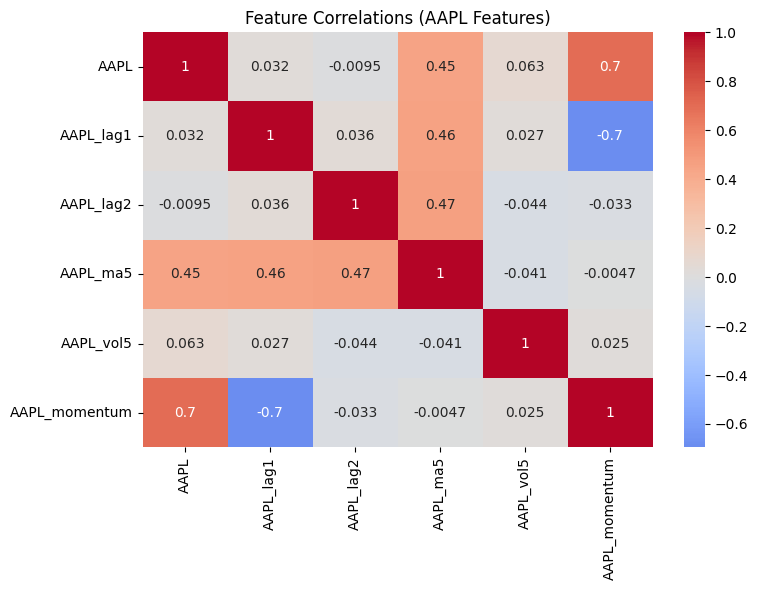

In [10]:
# Feature correlation
top_features = ['AAPL', 'AAPL_lag1', 'AAPL_lag2', 'AAPL_ma5', 'AAPL_vol5', 'AAPL_momentum']

plt.figure(figsize=(8, 6))
corr_matrix = features_df[top_features].corr()
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlations (AAPL Features)')
plt.tight_layout()
plt.show()

In [11]:
print("\n✓ Feature Engineering Complete")
print(f"\nFeatures ready for ML model:")
print(f"  • features_df: {features_df.shape}")
print(f"  • Date range: {features_df.index[0].date()} to {features_df.index[-1].date()}")


✓ Feature Engineering Complete

Features ready for ML model:
  • features_df: (1239, 70)
  • Date range: 2013-03-11 to 2018-02-07


In [12]:
# Save features for model training
features_df.to_csv('features_data.csv')
print("✓ Features saved to features_data.csv")

✓ Features saved to features_data.csv
